# Setup and Functions

In [2]:
import xarray as xr
from astropy.time import Time
from scipy.optimize import curve_fit
from scipy.constants import h, c, k
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def blackbody_fit_with_errors(
    dfs,
    x_col,
    y_col,
    yerr=None,                    # str (columna) o array o escalar o None
    xlabel=None,
    ylabel=None,
    title='Blackbody Fit with Residuals',
    labels=None,
    colors=None,
    savepath=None,
    show=True,

    # ---- Control de fuentes / estilo ----
    title_fontsize=16,
    axis_label_fontsize=14,
    tick_fontsize=12,
    legend_fontsize=11,
    residual_title_fontsize=None,
    residual_label_fontsize=None,
    residual_tick_fontsize=None,
    residual_legend_fontsize=None,

    figure_dpi=100,
    figure_size=(10, 7),
    grid_alpha=0.2,
    legend_loc='best'
):
    """
    Ajuste de cuerpo negro para uno o varios datasets con errores en y
    + gráfico de residuales normalizados.

    El modelo usa:
        F_lambda = B_lambda(T) * Omega_sun

    donde:
        - wavelength en nm
        - irradiance en W / m^2 / nm
        - Omega_sun se calcula a partir del diámetro angular solar:
          0°32'11.41''
    """

    # ------------------------- defaults residuales -------------------------
    if residual_title_fontsize is None:
        residual_title_fontsize = axis_label_fontsize + 1
    if residual_label_fontsize is None:
        residual_label_fontsize = axis_label_fontsize
    if residual_tick_fontsize is None:
        residual_tick_fontsize = tick_fontsize
    if residual_legend_fontsize is None:
        residual_legend_fontsize = max(8, legend_fontsize - 1)

    # ------------------------- normalizar entrada --------------------------
    if not isinstance(dfs, list):
        dfs = [dfs]
    n = len(dfs)

    if labels is None:
        labels = [f'Data {i+1}' for i in range(n)]
    if len(labels) != n:
        raise ValueError("labels debe tener la misma longitud que dfs")

    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, n))
    if len(colors) != n:
        raise ValueError("colors debe tener la misma longitud que dfs")

    # ------------------------- helpers --------------------------
    def parse_err_for_df(df, err_spec, fallback_len):
        if err_spec is None:
            return None
        if isinstance(err_spec, str):
            return df[err_spec].to_numpy(dtype=float)
        if np.isscalar(err_spec):
            return np.full(fallback_len, float(err_spec), dtype=float)
        arr = np.asarray(err_spec, dtype=float)
        if arr.shape[0] != fallback_len:
            raise ValueError("Error array debe tener la misma longitud que el dataframe")
        return arr

    def calculate_r_squared(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0

    # ------------------------- ángulo sólido solar --------------------------
    # diámetro angular: 0°32'11.41''
    diameter_arcsec = 32 * 60 + 11.41
    alpha_arcsec = diameter_arcsec / 2.0
    alpha_rad = alpha_arcsec / 206265.0
    Omega_sun = 2 * np.pi * (1 - np.cos(alpha_rad))

    def blackbody_model(wavelength_nm, T):
        """
        wavelength_nm en nm
        T en K

        devuelve irradiancia espectral en W / m^2 / nm
        """
        lam = wavelength_nm * 1e-9  # nm -> m

        exponent = (h * c) / (lam * k * T)
        exponent = np.clip(exponent, 1e-12, 700)

        B_lambda = (2 * h * c**2) / (lam**5) / (np.exp(exponent) - 1.0)
        # W / (m^2 sr m)

        F_lambda_m = B_lambda * Omega_sun
        # W / (m^2 m)

        F_lambda_nm = F_lambda_m * 1e-9
        # W / (m^2 nm)

        return F_lambda_nm

    # ------------------------- figura (2 filas) --------------------------
    fig, (ax_main, ax_res) = plt.subplots(
        2, 1,
        figsize=figure_size,
        dpi=figure_dpi,
        gridspec_kw={'height_ratios': [2, 1]}
    )
    fig.patch.set_facecolor('white')

    def style_axes(ax, xlabel_text, ylabel_text, title_text, t_fs, lab_fs, tick_fs):
        ax.set_xlabel(xlabel_text, fontsize=lab_fs)
        ax.set_ylabel(ylabel_text, fontsize=lab_fs)
        if title_text is not None:
            ax.set_title(title_text, fontsize=t_fs, pad=12)
        ax.tick_params(axis='both', labelsize=tick_fs, direction='in', length=5, width=1.1)
        for spine in ax.spines.values():
            spine.set_linewidth(1.1)
        ax.grid(alpha=grid_alpha, linestyle=':', linewidth=0.8)

    style_axes(
        ax_main,
        xlabel or x_col,
        ylabel or y_col,
        title,
        title_fontsize,
        axis_label_fontsize,
        tick_fontsize
    )

    # ------------------------- loop datasets --------------------------
    all_results = []
    all_residuals = []

    for df, lab, col in zip(dfs, labels, colors):
        x = df[x_col].to_numpy(dtype=float)
        y = df[y_col].to_numpy(dtype=float)
        cur_yerr = parse_err_for_df(df, yerr, len(df))

        # filtrar válidos
        mask = np.isfinite(x) & np.isfinite(y)
        if cur_yerr is not None:
            mask &= np.isfinite(cur_yerr) & (cur_yerr > 0)

        x = x[mask]
        y = y[mask]
        if cur_yerr is not None:
            cur_yerr = cur_yerr[mask]

        if len(x) < 3:
            raise ValueError(f"Dataset '{lab}': se requieren al menos 3 puntos válidos")

        # ordenar para graficar bien
        order = np.argsort(x)
        x = x[order]
        y = y[order]
        if cur_yerr is not None:
            cur_yerr = cur_yerr[order]

        # ajuste
        popt, pcov = curve_fit(
            blackbody_model,
            x, y,
            p0=[5778.0],
            sigma=cur_yerr,
            absolute_sigma=(cur_yerr is not None),
            bounds=([3000.0], [8000.0]),
            maxfev=20000
        )

        temperature = popt[0]
        temperature_err = np.sqrt(np.diag(pcov))[0]

        y_pred = blackbody_model(x, temperature)
        r2 = calculate_r_squared(y, y_pred)

        # residuales
        if cur_yerr is not None:
            residuals = (y - y_pred) / cur_yerr
        else:
            residuals = y - y_pred

        all_residuals.append((x, residuals, lab, col))

        # --- main plot ---
        ax_main.errorbar(
            x, y,
            yerr=cur_yerr,
            fmt='o',
            capsize=3,
            color=col,
            alpha=0.85,
            markersize=5,
            elinewidth=1.1,
            capthick=1.1,
            label=lab
        )

        x_line = np.linspace(np.min(x), np.max(x), 800)
        y_line = blackbody_model(x_line, temperature)
        ax_main.plot(
            x_line, y_line,
            '--',
            color=col,
            linewidth=1.8,
            label='Black body fit'
        )

        all_results.append({
            'dataset': lab,
            'temperature': temperature,
            'temperature_err': temperature_err,
            'r_squared': r2
        })

        print(f"\n--- Results for {lab} ---")
        print(f"Estimated temperature: {temperature:.6g} ± {temperature_err:.6g} K")
        print(f"R²:                    {r2:.6g}")

    ax_main.legend(
        loc=legend_loc,
        fontsize=legend_fontsize,
        frameon=True,
        fancybox=False,
        edgecolor='black'
    )

    ax_main.set_ylim(0, ax_main.get_ylim()[1])

    # ------------------------- residuales panel --------------------------
    style_axes(
        ax_res,
        xlabel or x_col,
        'Residuals',
        'Normalized Residuals' if yerr is not None else 'Residuals',
        residual_title_fontsize,
        residual_label_fontsize,
        residual_tick_fontsize
    )

    for x_data, res, lab, col in all_residuals:
        ax_res.scatter(
            x_data, res,
            color=col,
            alpha=0.7,
            s=30,
            edgecolors='none',
            label=lab
        )

    ax_res.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)

    if len(all_residuals) > 0:
        max_abs = max(np.max(np.abs(r)) for _, r, _, _ in all_residuals if len(r) > 0)
        if np.isfinite(max_abs) and max_abs > 0:
            ax_res.set_ylim(-1.1 * max_abs, 1.1 * max_abs)

    ax_res.legend(
        loc=legend_loc,
        fontsize=residual_legend_fontsize,
        frameon=True,
        fancybox=False,
        edgecolor='black'
    )

    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=figure_dpi, bbox_inches='tight', facecolor='white')

    if show:
        plt.show()

    return all_results, fig




In [4]:
ds = xr.open_dataset("data/sorce_sim_L3_c24h_0240nm_2413nm_20030414_20200225.nc")

t = Time(ds["time"].values, format="jd")
ds["time"] = ("time", t.to_datetime())

df = ds.to_dataframe().reset_index('wavelength')
print(df.head())

                     wavelength  irradiance  uncertainty  quality
time                                                             
2003-04-14 12:00:00  240.020004    0.041338     0.000399       64
2003-04-14 12:00:00  240.110001    0.042611     0.000403       64
2003-04-14 12:00:00  240.190002    0.043288     0.000405       64
2003-04-14 12:00:00  240.279999    0.042863     0.000409       64
2003-04-14 12:00:00  240.369995    0.041678     0.000412       64


In [10]:
ds.attrs

{'title': 'SORCE-SIM SSI (Solar Spectral Irradiance) V27',
 'version': 'V01.01',
 'file_version': 'V01.05',
 'time_cadence': '24 hour',
 'institution': 'Laboratory for Atmospheric and Space Physics, University of Colorado - Boulder',
 'date_created': 'Wed Apr  7 03:40:08 2021 UTC',
 'time_coverage_start_jd': '2452744.000000',
 'time_coverage_end_jd': '2458905.000000',
 'contributor_name': 'Steven Penton (steven.penton@lasp.colorado.edu)',
 'history': 'This file was created after the conclusion of the SORCE mission. This is data version 01 of the SIM data. The version of this file is V01.05 . File versions greater than V01.04 use double precision for irradiance.',
 'DOI': 'https://doi.org/10.5067/LDDKZ3PXZZ5G'}

# Analysis

In [6]:
data = df.loc['2006-10-27 12:00:00'].reset_index(drop=True).copy()
data
data.describe()

,wavelength,irradiance,uncertainty,quality
count,1235.000000,1235.000000,1235.000000,1235.000000
mean,552.826599,0.752969,0.000625,0.017814
std,464.644928,0.636563,0.000628,0.187986
min,240.020004,0.035762,0.000062,0.000000
25%,276.305008,0.189553,0.000231,0.000000
50%,347.559998,0.605870,0.000339,0.000000
75%,581.569977,1.127360,0.000876,0.000000
max,2412.340088,2.104573,0.003037,2.000000


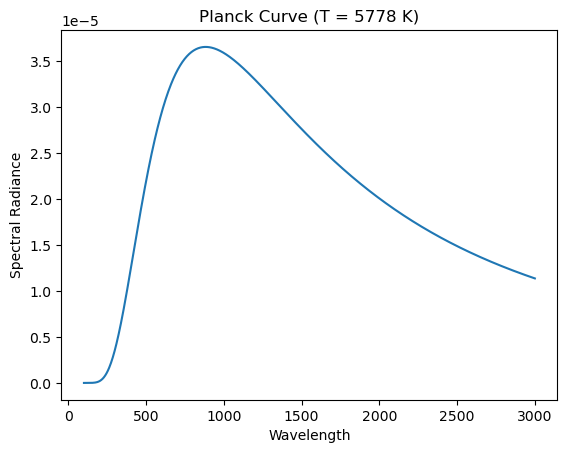

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.modeling.models import BlackBody
import astropy.units as u
from astropy.visualization import quantity_support

# temperature of the Sun
T = 5778 * u.K

# create model
bb = BlackBody(temperature=T)

# wavelength grid
wavelength = np.linspace(100, 3000, 1000) * u.nm

# evaluate Planck function
flux = bb(wavelength)

# plot
with quantity_support():
    plt.plot(wavelength, flux)
    plt.xlabel("Wavelength")
    plt.ylabel("Spectral Radiance")
    plt.title("Planck Curve (T = 5778 K)")
    plt.show()



--- Results for Data SORCE/SIM ---
Estimated temperature: 5536.82 ± 0.00945971 K
R²:                    0.854846


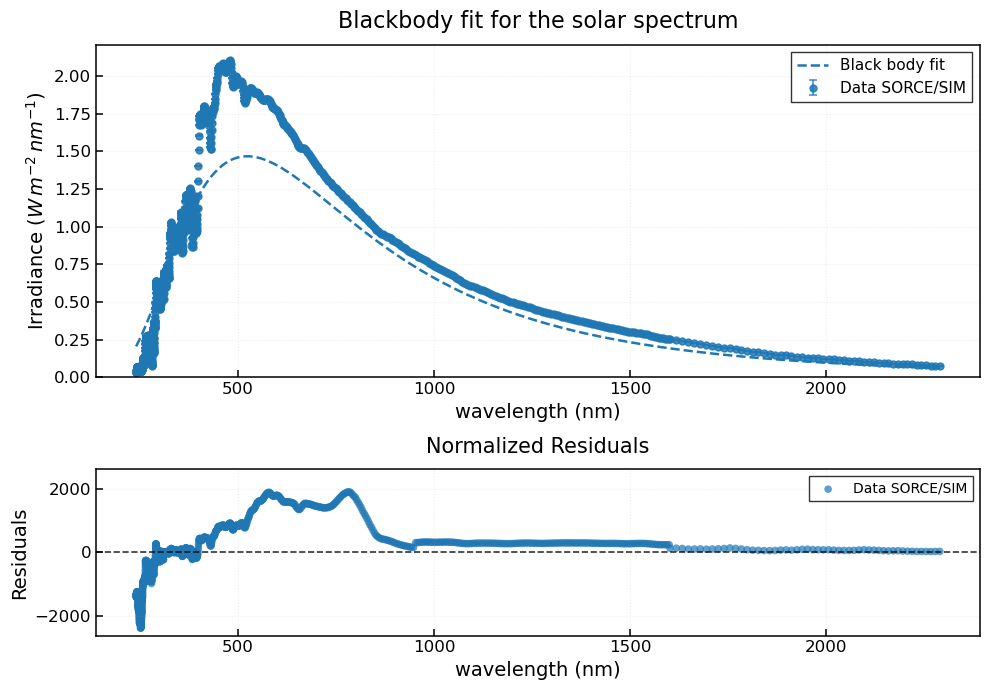

In [15]:
filtered_data = data[data["quality"] == 0].copy()

results, fig = blackbody_fit_with_errors(
    dfs=filtered_data,
    x_col="wavelength",
    y_col="irradiance",
    yerr="uncertainty",
    xlabel="wavelength (nm)",
    ylabel=r"Irradiance ($W\,m^{-2}\,nm^{-1}$)",
    title="Blackbody fit for the solar spectrum",
    labels=["Data SORCE/SIM"],
    legend_loc="best"
)
